<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/High_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Data and Preprocessing

First, I will load the `Hindustan_copper.ods` file using `pd.read_excel`, parse the 'Date' column, set it as the index, sort the index, and then reindex to ensure business day frequency. Finally, I'll extract the 'High' column as our target series.

In [ ]:
!pip install pmdarima
!pip install odfpy
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima
import matplotlib.pyplot as plt

# Load the .ods file
df = pd.read_excel('/content/Hindustan_copper.ods', engine='odf')

# Parse the datetime column, set as index, sort, and assign business day frequency
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime').sort_index()
df = df.asfreq('B', method='ffill') # 'B' for business day frequency

# Extract the 'High' column as the target series
target_series = df['high']

# Display the first few rows and info to verify
print("DataFrame head:")
display(df.head())
print("\nTarget series info:")
target_series.info()

DataFrame head:


,symbol,open,high,low,close,volume
datetime,,,,,,
2016-01-04 00:00:00+05:30,HINDALCO,84.20,85.90,80.4,80.75,8706224
2016-01-05 00:00:00+05:30,HINDALCO,82.00,83.95,80.6,82.60,9819068
2016-01-06 00:00:00+05:30,HINDALCO,82.40,82.85,79.7,80.55,6494446
2016-01-07 00:00:00+05:30,HINDALCO,79.00,79.40,76.1,76.65,8098318
2016-01-08 00:00:00+05:30,HINDALCO,77.45,78.15,75.2,76.90,6800939



Target series info:
<class 'pandas.core.series.Series'>
DatetimeIndex: 2671 entries, 2016-01-04 00:00:00+05:30 to 2026-03-30 00:00:00+05:30
Freq: B
Series name: high
Non-Null Count  Dtype  
--------------  -----  
2671 non-null   float64
dtypes: float64(1)
memory usage: 41.7 KB


### Split Data into Train and Test Sets

I will split the data into 80% for training and 20% for testing, maintaining the time order of the series.

In [ ]:
# Split into 80% train and 20% test maintaining time order
train_size = int(len(target_series) * 0.8)
train, test = target_series[0:train_size], target_series[train_size:]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

Train set size: 2136
Test set size: 535


### Find Optimal ARIMA Order using `auto_arima`

Now, I will use `auto_arima` to automatically find the best `(p, d, q)` order for the ARIMA model based on the training data. I'll set `seasonal=False` as requested.

In [ ]:
# Find the best (p,d,q) order using auto_arima
# Suppress warnings and errors for cleaner output during stepwise search
stepwise_model = auto_arima(train, seasonal=False, stepwise=True,
                            suppress_warnings=True, error_action='ignore',
                            trace=False) # Set trace=True for more verbose output if needed

best_order = stepwise_model.order
print(f"Best ARIMA Order (p,d,q): {best_order}")

Best ARIMA Order (p,d,q): (1, 1, 0)


### Walk-Forward Validation and Prediction

Next, I'll perform walk-forward validation. For each point in the test set, the ARIMA model will be retrained on all data up to that point, and then a 1-step-ahead prediction will be made. The actual value will be appended to the history for the next iteration.

In [ ]:
# Walk-forward validation
history = [x for x in train]
predictions = list()

for t in range(len(test)):
    model = ARIMA(history, order=best_order)
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test.iloc[t] # Use iloc for position-based indexing on the Series
    history.append(obs)
    # print(f'predicted={yhat:.2f}, expected={obs:.2f}')

# Convert predictions to a pandas Series with the test index
predictions = pd.Series(predictions, index=test.index)

# Calculate and print RMSE
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'Test RMSE: {rmse:.3f}')

Test RMSE: 11.973


### Visualize Results

Finally, I'll create a figure with two subplots:

*   **Left Subplot**: A full view showing the training data, actual test data, and the ARIMA predictions for the test set.
*   **Right Subplot**: A zoomed-in view focusing only on the test period, comparing actual and predicted values.

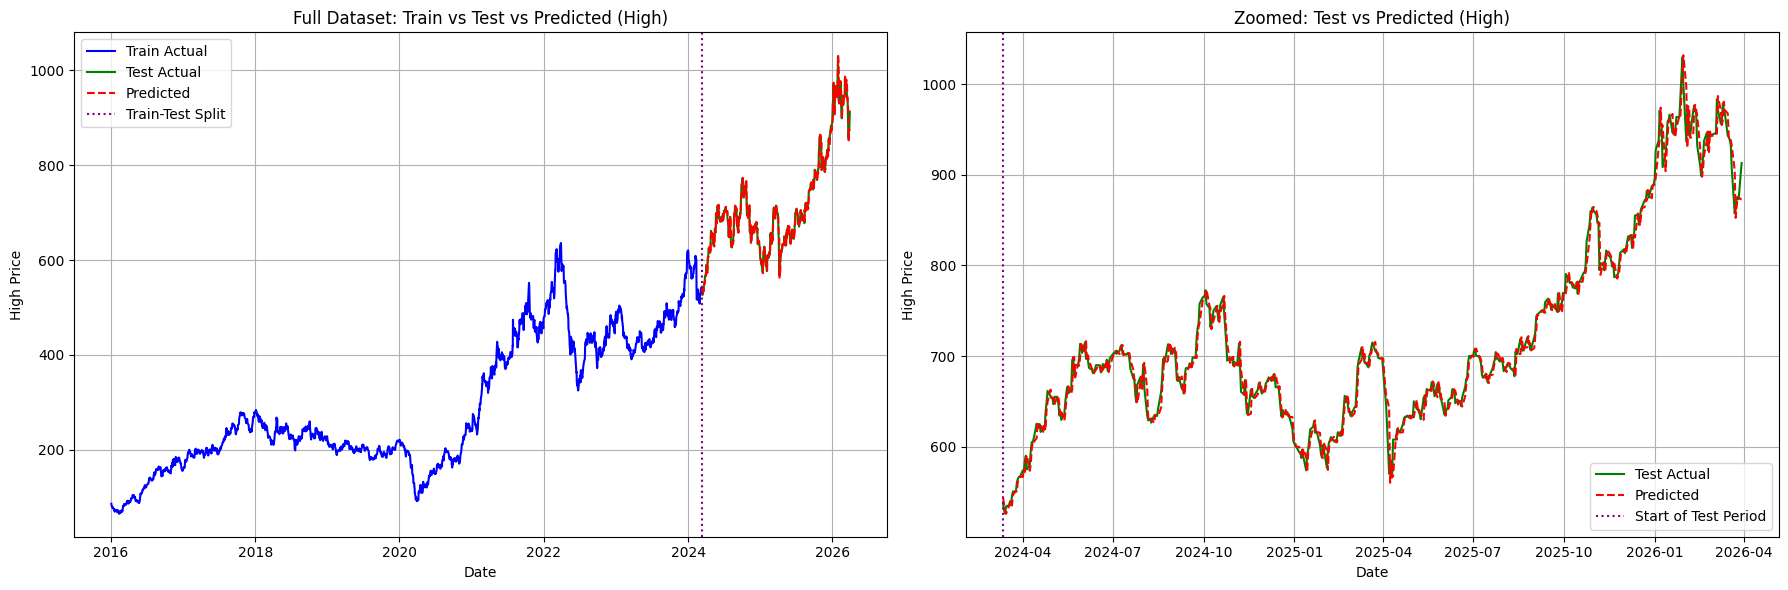


Final ARIMA Order (p,d,q): (1, 1, 0)
Final Test RMSE: 11.973


In [ ]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots
plt.figure(figsize=(18, 6))

# Left subplot: Full Dataset View
plt.subplot(1, 2, 1)
plt.plot(train.index, train.values, color='blue', label='Train Actual')
plt.plot(test.index, test.values, color='green', label='Test Actual')
plt.plot(predictions.index, predictions.values, color='red', linestyle='--', label='Predicted')
plt.axvline(x=train.index[-1], color='purple', linestyle=':', label='Train-Test Split')
plt.title('Full Dataset: Train vs Test vs Predicted (High)')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)

# Right subplot: Zoomed Test-Only View
plt.subplot(1, 2, 2)
plt.plot(test.index, test.values, color='green', label='Test Actual')
plt.plot(predictions.index, predictions.values, color='red', linestyle='--', label='Predicted')
plt.axvline(x=test.index[0], color='purple', linestyle=':', label='Start of Test Period')
plt.title('Zoomed: Test vs Predicted (High)')
plt.xlabel('Date')
plt.ylabel('High Price')
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Print final ARIMA order and RMSE again for easy access
print(f"\nFinal ARIMA Order (p,d,q): {best_order}")
print(f"Final Test RMSE: {rmse:.3f}")